In [1]:
# from investment_analyser.data_loader import DataLoader
from investment_analyser.portfolio import Portfolio
# import os
import pandas as pd
# import requests
# import json
# from bs4 import BeautifulSoup
import numpy as np
from investment_analyser.security import Security
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy.interpolate import PchipInterpolator

In [33]:
folder = "C:/Users/joche/GitHub/investment/investment-analyser/data"
sec_filepath = folder + "/security/iShares-MSCI-Japan-GBP-Hedged-UCITS-ETF-Acc_fund.xlsx"

excel = pd.read_excel(sec_filepath, sheet_name=[1,2], header=None)
sheet1 = excel[1]

# Name of the security (first row, first column)
name = sheet1.iloc[0, 0]

# Helper to find the first row in column 0 that contains a given label (case-insensitive)
def _find_row(label):
    col0 = sheet1.iloc[:, 0].astype(str)
    mask = col0.str.contains(label, case=False, na=False)
    if not mask.any():
        raise ValueError(f"Could not find row containing '{label}' in column 0 of: {fpath}")
    return int(np.where(mask.values)[0][0])

# Find inception date (first entry whose column-0 contains "Date")
row_date = _find_row("Date")
inception = sheet1.iloc[row_date, 1]
inception_tick = sec.convert_time(np.asarray([inception]), time_form="iShares")[0]

# Find type (row where column-0 contains "Class")
row_type = _find_row("Class")
type = sheet1.iloc[row_type, 1]

# Find benchmark (row where column-0 contains "Benchmark")
row_benchmark = _find_row("Benchmark")
benchmark = sheet1.iloc[row_benchmark, 1]

# Find currency (row where column-0 contains "Base Currency")
row_currency = _find_row("Base Currency")
currency = sheet1.iloc[row_currency, 1]

orig_tick_time = sec.convert_time(np.asarray(excel[2][0][1:]), time_form="iShares")
orig_return = excel[2][5][1:]

# Remove entries with '--' and reverse order (from start to now)
numeric_entries = ~orig_return.str.contains("-", na=False)
orig_tick_time = orig_tick_time[numeric_entries][::-1]
orig_return = np.asarray(orig_return[numeric_entries][::-1], dtype=float)

print(orig_tick_time[1:] - orig_tick_time[:-1])
ind = np.argmin(orig_tick_time[1:] - orig_tick_time[:-1])
print(orig_tick_time[1:][ind], orig_tick_time[:-1][ind])
print(excel[2][0][1:][numeric_entries][::-1][ind-2:ind+2])
print(sec.convert_time(excel[2][0][1:][numeric_entries][::-1][ind-2:ind+2], time_form="iShares"))
tick_time = np.arange(orig_tick_time[0], orig_tick_time[-1]+1, 1, dtype=int)
# Perform interpolation (pchip is used for most accurate interpolation, without overshooting)
# return_series = PchipInterpolator(orig_tick_time, orig_return)(tick_time)

# Find unique elements and their counts
unique_elements, counts = np.unique(orig_tick_time, return_counts=True)

# Identify duplicates
duplicates = unique_elements[counts > 1]
print("Duplicates:", duplicates, max(counts))

print(sec.convert_time(["31/Dec/2016","01/Jan/2017"], time_form="iShares"))
2012%4

[1 1 1 ... 1 1 1]
22281 22281
3443    27/Dec/2012
3442    28/Dec/2012
3441    31/Dec/2012
3440    01/Jan/2013
Name: 0, dtype: str
[22277 22278 22281 22281]
Duplicates: [22281] 2
[23742 23742]


0

In [ ]:
p = Portfolio()

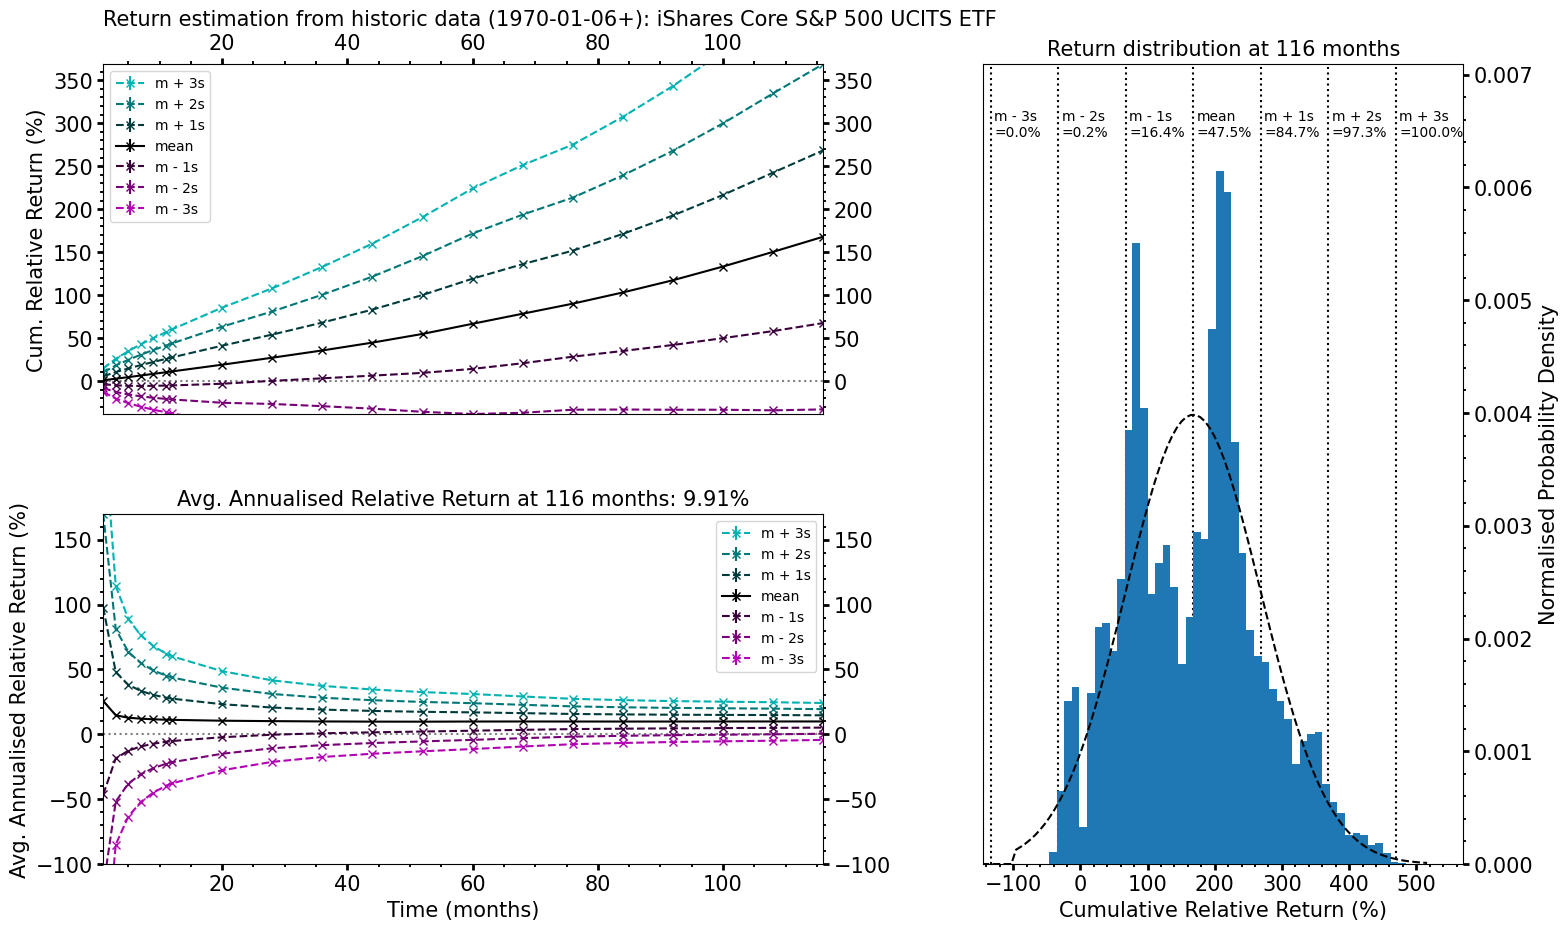

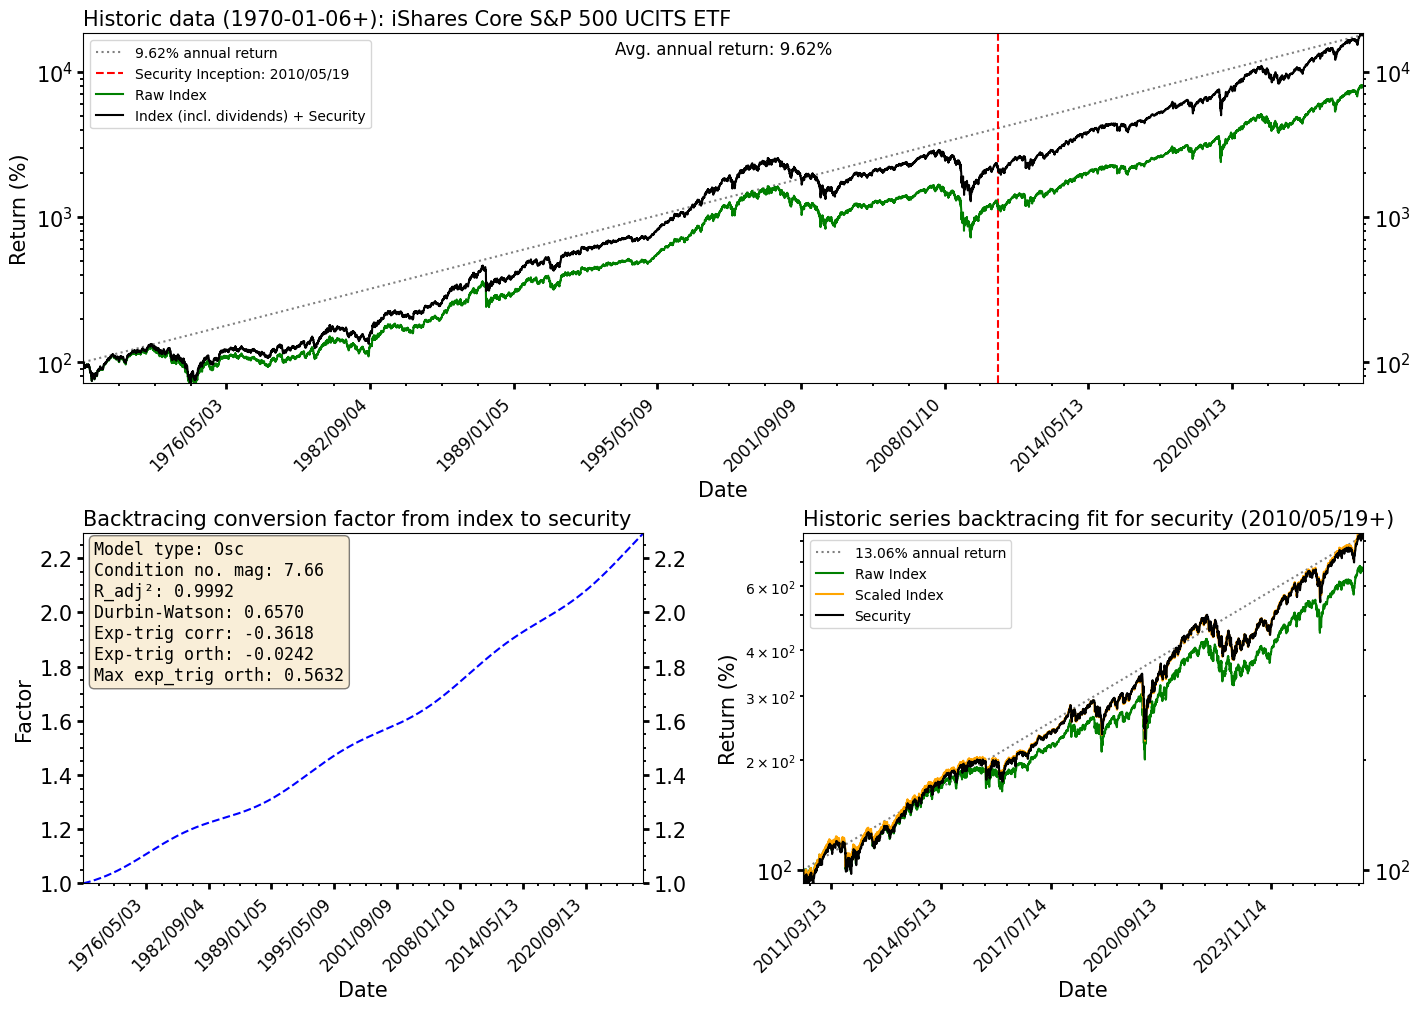

In [2]:
# p = Portfolio()
folder = "C:/Users/joche/GitHub/investment/investment-analyser/data"
# sec_filepath = folder + "/security/iShares-Nikkei-225-UCITS-ETF-JPY-Acc_fund.xlsx"
# sec_filepath = folder + "/security/iShares-MSCI-Japan-GBP-Hedged-UCITS-ETF-Acc_fund.xlsx"
# index_filepath = folder + "/index/125141 - MSCI Japan 100% Hedged to GBP Index  - FULL - 1998-12-31 - 2026-07-07  - Monthly.xlsx"
sec_filepath = folder + "/security/iShares-Core-SP-500-UCITS-ETF-USD-Acc_fund.xlsx"
index_filepath = folder + "/index/iShares_Core_S&P_500_UCITS_ETF-yahoo.csv"
# pd.read_excel(index_filepath)
sec = Security(sec_filepath, index_filepath, dist_fund=False, calc_mat=True)
sec.plot_security()
# sec.inception_tick

56.48459958932238 54.39208266381208 7.331159446258262
[ 6581  6582  6583 ... 27210 27211 27212]
[    518400     604800     691200 ... 1782864000 1782950400 1783036800]
(14049,)
(14049,)
(0,)
[0.0e+00 2.0e+08 4.0e+08 6.0e+08 8.0e+08 1.0e+09 1.2e+09 1.4e+09 1.6e+09
 1.8e+09] ['01/01/70', '03/05/76', '04/09/82', '05/01/89', '09/05/95', '09/09/01', '10/01/08', '13/05/14', '13/09/20', '15/01/27']


C:\Users\joche\AppData\Local\Temp\ipykernel_70152\1211393188.py:62: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  datetime.datetime.utcfromtimestamp(int(np.round(x))).strftime("%d/%m/%y")


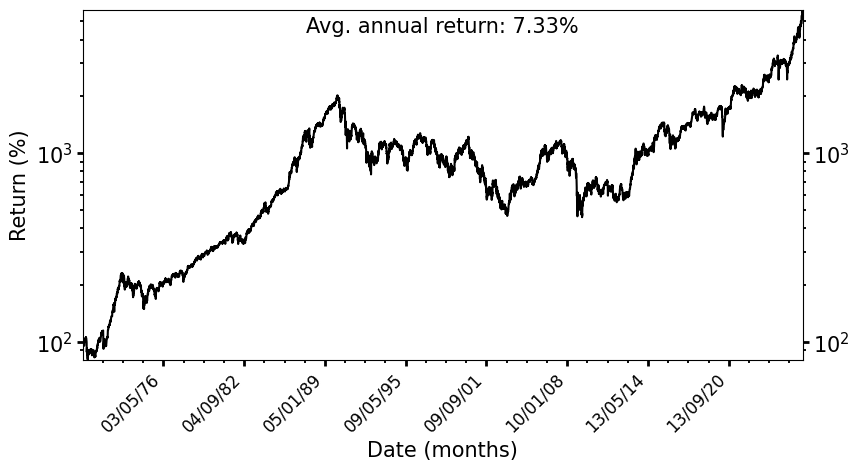

In [9]:
return_series = sec.return_series/sec.return_series[0] * 100
tick_time = sec.tick_time
orig_tick_time = sec.orig_tick_time
title_input = ""
orig_return_series = return_series[np.isin(tick_time, orig_tick_time)]
# new_orig_t = tick_time[np.isin(tick_time, orig_tick_time)]
year_diff = (orig_tick_time[-1] - orig_tick_time[0])/365.25
avg_annual_return = (((orig_return_series[-1] - orig_return_series[0])/100)**(1/year_diff) - 1)*100
print(year_diff, (orig_return_series[-1] - orig_return_series[0])/100, avg_annual_return)
print(orig_tick_time)

orig_tick_time = (orig_tick_time - sec.convert_time(
    np.array(["01/Jan/1970"]), time_form="iShares"
)) * 86400
print(orig_tick_time)
# print(new_orig_t, orig_tick_time)|
# print(orig_tick_time[np.isin(orig_tick_time, new_orig_t)].shape)
print(orig_return_series.shape)
print(orig_tick_time.shape)
print(orig_tick_time[np.isin(orig_tick_time, tick_time)].shape)

# Create figure with appropriate size
fig = plt.figure(figsize=(16, 10))

# Cumulative return
ax = fig.add_axes([0.1, 0.55, 0.45, 0.35])
ax.text(
    0.5,
    0.98,
    f"Avg. annual return: {avg_annual_return:.2f}%",
    ha="center",
    va="top",
    fontsize=sec.fontsize,
    transform=ax.transAxes,
)
plt.title(title_input, fontsize=sec.fontsize, loc="left")

ax.plot(orig_tick_time, orig_return_series, color="black")

lim_max = max(return_series)
lim_min = min(max([0, min(return_series)]),100)
plt.ylim([lim_min, lim_max])
plt.xlim([orig_tick_time[0], orig_tick_time[-1]])
plt.yscale("log")

plt.ylabel("Return (%)", fontsize=sec.fontsize)

ax.tick_params(left=True, right=True, labelleft=True, labelright=True)
plt.yticks(fontsize=sec.fontsize)
plt.tick_params(axis="both", which="major", width=sec.tickwidth, length=sec.ticklength)
plt.minorticks_on()
plt.tick_params(
    axis="both", which="minor", width=sec.tickwidth * 2 / 3, length=sec.ticklength / 2
)
plt.tick_params(axis="both", which="both", left=True, right=True)

plt.xlabel("Date (months)", fontsize=sec.fontsize)
xticks = ax.get_xticks()
# xticks = np.append(xticks, orig_tick_time[-1])

xtick_labels = [
    datetime.datetime.utcfromtimestamp(int(np.round(x))).strftime("%d/%m/%y")
    for x in xticks
]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=sec.fontsize-3, rotation=45, ha="right")
plt.xlim([orig_tick_time[0], orig_tick_time[-1]])
print(xticks, xtick_labels)


In [15]:
from scipy.interpolate import PchipInterpolator

excel = pd.read_csv(index_filepath)

if "Date" in excel.columns:  # Old format, with download API:
    # Extract time
    datetime_series = pd.to_datetime(excel["Date"][1:], format="%d/%m/%Y")

    timestamps = datetime_series.apply(lambda x: x.timestamp())
elif "Timestamp" in excel.columns:  # New format from json data in chart
    timestamps = excel["Timestamp"][1:]
else:
    raise ValueError(
        "The following Yahoo data file has an unsupported format: \n"
        + fpath
        + "\n"
        + "If this file type should be supported, implement it in: \n"
        + sec.script_location
    )

# Convert time to iShares format
orig_index_tick_time = sec.convert_time(np.array(timestamps), time_form="Generic")

# Extract return series
orig_return = np.array(excel["Adj Close"][1:], dtype=float)

valid_entries = ~np.isnan(orig_return)
orig_return = orig_return[valid_entries]
orig_index_tick_time = orig_index_tick_time[valid_entries]

## Interpolate data to full dataset
# (interpolation is done so the return can be calculated on all data and sampling
# biases are removed)
index_tick_time = np.arange(orig_index_tick_time[0], orig_index_tick_time[-1], 1, dtype=int)
# Perform interpolation (pchip is used for most accurate interpolation, without overshooting)
index_return_series = PchipInterpolator(orig_index_tick_time, orig_return)(
    index_tick_time
)

In [17]:
index_return_series

array([ 2406.2199707 ,  2394.95996094,  2283.67993164, ...,
       69743.54795344, 69741.60719161, 69737.6875    ], shape=(20636,))

In [14]:
int(sec.convert_time(np.array(['01/Jan/1970']))[0]

6575

In [26]:
excel = pd.read_excel("C:/Users/joche/GitHub/investment/investment-analyser/data/index/119010 - MSCI USA Consumer Staples Index  - FULL - 1998-12-31 - 2026-07-06  - Monthly.xlsx")
excel
time = excel["Unnamed: 0"][5:]
index_return = excel["Unnamed: 1"][5:]
time
timestamps = pd.to_datetime(time, format='%Y-%m-%d').apply(lambda x: x.timestamp())
index_return

5             100
6       97.997065
7       93.487876
8       91.979813
9       92.846541
          ...    
331    654.842576
332    604.930188
333     625.22627
334    602.390505
335     610.32524
Name: Unnamed: 1, Length: 331, dtype: object

In [2]:
sec = Security("C:/Users/joche/GitHub/investment/investment-analyser/data/security/iShares-Core-SP-500-UCITS-ETF-USD-Acc_fund.xlsx")

In [11]:
sec.inception

'19/May/2010'

In [ ]:
url = "https://www.msci.com/indexes/index/700999/msci-europe-minimum-volatility-index-eur"

response = requests.get(url, headers={"User-agent": "InkJDog"})
# pd.read_html(response.content)

In [30]:
response.content

b'<!DOCTYPE html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no"><title>Challenge Validation</title><link rel="stylesheet" type="text/css" href="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/dj9dTn/B7M1hY"><script type="text/javascript">function cp_clge_done(){location.reload(true);}</script><script src="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/MCl1TC/4RYGwt" async defer></script><script type="text/javascript">sessionStorage.setItem(\'data-duration\', 10);</script></head><body><div class="sec-container"><div id="sec-text-container"><iframe title="Challenge Message" id="sec-text-if" class="custmsg crypto" src="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/d2t3Az/Q1VGQAAQ"></iframe></div><div id="sec-if-container"><iframe title="Challenge Content" id="sec-cpt-if" provider="crypto" class="crypto" challenge="eyJ0b2tlbiI6IkFBUUFBQUFOX19fX19fYzdqelBYamVOel9uVXBrWUhXRXJoeGg4dDF1a1RPbnVld0RzclFfQzJmenBMQmNqOEVaMmZ

In [25]:
url = "https://query2.finance.yahoo.com/v8/finance/chart/%5EFTSE?period1=-1325583000&period2=1724284800&interval=1d&events=history&includeAdjustedClose=true"

response = requests.get(url, headers={"User-agent": "InkJDog"})

In [28]:
from datetime import datetime

# Example timestamp (in seconds since epoch)
timestamp = 1227168000

# Convert to datetime object
dt_object = datetime.fromtimestamp(timestamp)
dt_object

datetime.datetime(2008, 11, 20, 8, 0)

In [27]:
js = json.loads(response.content)

df = pd.DataFrame(
    data={
        "Timestamp": js["chart"]["result"][0]["timestamp"],
        "Adj Close": js["chart"]["result"][0]["indicators"]["adjclose"][0]["adjclose"],
    },
    dtype=float,
)
df

,Timestamp,Adj Close
0,4.419648e+08,997.500000
1,4.420512e+08,998.599976
2,4.421376e+08,1015.799988
3,4.422240e+08,1029.000000
4,4.424832e+08,1034.599976
...,...,...
10443,1.723705e+09,8347.400391
10444,1.723792e+09,8311.400391
10445,1.724051e+09,8356.900391
10446,1.724137e+09,8273.299805


In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
soup

In [ ]:
soup.select_one("meta")

In [21]:

summary = soup.select_one("#quote-summary")
print(summary)
# tables = pd.read_html(str(summary))

# df = pd.concat(tables, axis=0, ignore_index=True)
# df.columns = ["Field", "Value"]

# print(df)

None


In [3]:
dl = DataLoader()

In [4]:
dl.xml_to_xlsx('C:/\Users\\joche\\Downloads\\STOXX-Europe-600-Utilities-UCITS-ETF-DE_fund.xls')

In [62]:
excel = pd.read_excel('C:\\Users\\joche\\Downloads\\STOXX-Europe-600-Utilities-UCITS-ETF-DE_fund.xlsx', sheet_name=[1,2,4], header=None)



In [65]:
excel[4]

,0,1,2
0,Ex-Date,Payable Date,Total Distribution
1,15/Jul/2026,15/Jul/2026,0.626892
2,15/Apr/2026,15/Apr/2026,0.226545
3,15/Jan/2026,15/Jan/2026,0.141646
4,15/Oct/2025,15/Oct/2025,0.370157
...,...,...,...
76,16/Jul/2007,16/Jul/2007,1.4302
77,17/Jul/2006,17/Jul/2006,0.8884
78,15/Jul/2005,15/Jul/2005,1.1359595
79,15/Jul/2004,15/Jul/2004,0.7202498


[1 2 4]
[ True  True  True]
[20 30 50]


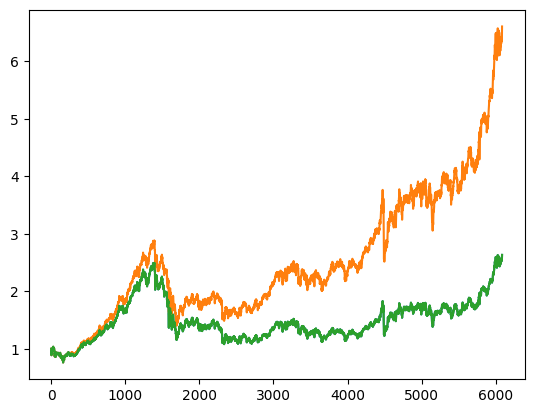

In [80]:
import matplotlib.pyplot as plt
import numpy as np

a = excel[2][2][1:]
c = excel[2][5][1:]
securities = excel[2][3][1:]
assets = excel[2][4][1:]

numeric_entries = np.logical_and(np.logical_and(~c.str.contains("-", na=False),~a.str.contains("-", na=False)),
                                 np.logical_and(~securities.str.contains("-", na=False),~assets.str.contains("-", na=False)))
a = np.asarray(a[numeric_entries][::-1],dtype=float)
a = a/a[0]

c = np.asarray(c[numeric_entries][::-1],dtype=float)
c = c/c[0]

securities = np.asarray(securities[numeric_entries][::-1],dtype=float)
assets = np.asarray(assets[numeric_entries][::-1],dtype=float)
assets_per_sec = assets/securities
assets_per_sec = assets_per_sec/assets_per_sec[0]

b = np.linspace(0,6085,a.shape[0])
# d = np.linspace(0,6085,760)
plt.plot(b,a)
plt.plot(b,c)
plt.plot(b,assets_per_sec)
plt.show()

In [92]:
orig_return = c
orig_tick_time = b

dividend_return = excel[4][2][1:]
dividend_tick_time = b[::-1]

# Remove entries with '--' and reverse order (from start to now)
numeric_entries_div = ~dividend_return.str.contains("-", na=False)
dividend_tick_time = dividend_tick_time[numeric_entries_div][::-1]
dividend_return = np.asarray(dividend_return[numeric_entries_div][::-1], dtype=float)

# Extract per security NAV in security currency
nav = excel[2][2][1:]
print(nav.shape, numeric_entries.shape)
nav = nav[numeric_entries][::-1]

# Align NAV values to the dividend dates in a vectorized way.
idx = np.searchsorted(orig_tick_time, dividend_tick_time)

# Check if the dividends do actually fall within the nav time-series (in principle
# it always should)
print(idx)
print(orig_tick_time)
print(orig_tick_time)
print(idx[-1],len(orig_tick_time))
if idx[-1] >= len(orig_tick_time):
    idx = idx[:-1]
    dividend_return = dividend_return[:-1]
    dividend_tick_time = dividend_tick_time[:-1]
print(idx)

if not np.all(orig_tick_time[idx] == dividend_tick_time):
    print(orig_tick_time[idx] == dividend_tick_time)
    print(orig_tick_time[idx[0]], dividend_tick_time[0])
    raise ValueError("Some dividend dates could not be matched to NAV dates.")

dividend_nav = np.asarray(nav[idx], dtype=float)
rel_dividend_return = dividend_return / dividend_nav

# Apply dividend effects to all subsequent returns in a vectorized way.
dividend_factors = np.ones(len(orig_return), dtype=float)
dividend_factors[idx] = rel_dividend_return
dividend_factors = np.cumprod(dividend_factors)
# orig_return = orig_return * dividend_factors

(6086,) (6086,)
[   0   77  154  231  308  385  461  538  615  692  769  845  922  999
 1076 1153 1229 1306 1383 1460 1537 1614 1690 1767 1844 1921 1998 2074
 2151 2228 2305 2382 2458 2535 2612 2689 2766 2842 2919 2996 3073 3150
 3227 3303 3380 3457 3534 3611 3687 3764 3841 3918 3995 4071 4148 4225
 4302 4379 4455 4532 4609 4686 4763 4840 4916 4993 5070 5147 5224 5300
 5377 5454 5531 5608 5684 5761 5838 5915 5992 6068]
[0.00000000e+00 1.00280158e+00 2.00560316e+00 ... 6.08299440e+03
 6.08399720e+03 6.08500000e+03]
[0.00000000e+00 1.00280158e+00 2.00560316e+00 ... 6.08299440e+03
 6.08399720e+03 6.08500000e+03]
6068 6069
[   0   77  154  231  308  385  461  538  615  692  769  845  922  999
 1076 1153 1229 1306 1383 1460 1537 1614 1690 1767 1844 1921 1998 2074
 2151 2228 2305 2382 2458 2535 2612 2689 2766 2842 2919 2996 3073 3150
 3227 3303 3380 3457 3534 3611 3687 3764 3841 3918 3995 4071 4148 4225
 4302 4379 4455 4532 4609 4686 4763 4840 4916 4993 5070 5147 5224 5300
 5377 5454 5531 56

ValueError: Some dividend dates could not be matched to NAV dates.

In [ ]:
name = excel[1][0][0]  # Name of the security
inception = excel[1][1][6]  # Inception data
inception_tick = convert_time(
    np.asarray([inception]), time_form="iShares"
)[0]
type = excel[1][1][10]
benchmark = excel[1][1][11]
currency = excel[1][1][8]

orig_tick_time = convert_time(np.asarray(excel[2][0][1:]), time_form="iShares")
orig_return = excel[2][2][1:]

# Remove entries with '--' and reverse order (from start to now)
numeric_entries = ~orig_return.str.contains("-", na=False)
orig_tick_time = orig_tick_time[numeric_entries][::-1]
orig_return = orig_return[numeric_entries][::-1]

# Turn array into float
orig_return = np.asarray(orig_return, dtype=float)